<a href="https://colab.research.google.com/github/gauravjha201/Brain_Tumor_Adversarial_Robustness/blob/main/Stage_B_FGSM_Attack.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [3]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix,classification_report


In [4]:
DATASET_PATH = "/content/drive/MyDrive/Br35H"

val_dataset = tf.keras.preprocessing.image_dataset_from_directory(
    DATASET_PATH,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(224,224),
    batch_size=32
)

val_dataset = val_dataset.map(lambda x, y: (x/255.0, y))

Found 3023 files belonging to 2 classes.
Using 604 files for validation.


In [5]:
model=tf.keras.models.load_model("/content/drive/MyDrive/baseline_model.h5")
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,083 (9.24 MB)

 Trainable params: 164,097 (641.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

 Optimizer params: 2 (12.00 B)

In [6]:
clean_loss,clean_acc=model.evaluate(val_dataset)
print(f"clean_acc: {clean_acc*100:.2f}")

19/19 ━━━━━━━━━━━━━━━━━━━━ 92s 3s/step - accuracy: 0.9834 - loss: 0.0651
clean_acc: 98.34


FGSM Evaluation ( Epsilon )

In [7]:
def fgsm_attack(model, images, labels, epsilon):
    images = tf.cast(images, tf.float32)

    labels = tf.reshape(labels, (-1, 1))

    with tf.GradientTape() as tape:
        tape.watch(images)
        predictions = model(images)
        loss = tf.keras.losses.binary_crossentropy(labels, predictions)

    gradient = tape.gradient(loss, images)
    signed_grad = tf.sign(gradient)

    adv_images = images + epsilon * signed_grad
    adv_images = tf.clip_by_value(adv_images, 0, 1)

    return adv_images

Predictions on FGSM (for metrics)

In [8]:
y_true=[]
y_pred_clean=[]
y_pred_fgsm=[]

epsilon=0.03

for images,labels in val_dataset:
  adv_images=fgsm_attack(model,images,labels,epsilon)

  preds_clean=model.predict(images)
  preds_clean=(preds_clean>0.5).astype(int)

  preds_fgsm=model.predict(adv_images)
  preds_fgsm=(preds_fgsm>0.5).astype(int)

  y_true.extend(labels.numpy())
  y_pred_clean.extend(preds_clean)
  y_pred_fgsm.extend(preds_fgsm)





1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━

In [9]:
print("=== CLEAN DATA ===")
print(confusion_matrix(y_true,y_pred_clean))
print("\n=== FGSM DATA ===")
print(confusion_matrix(y_true,y_pred_fgsm))


=== CLEAN DATA ===
[[294   4]
 [  6 300]]

=== FGSM DATA ===
[[  3 295]
 [295  11]]


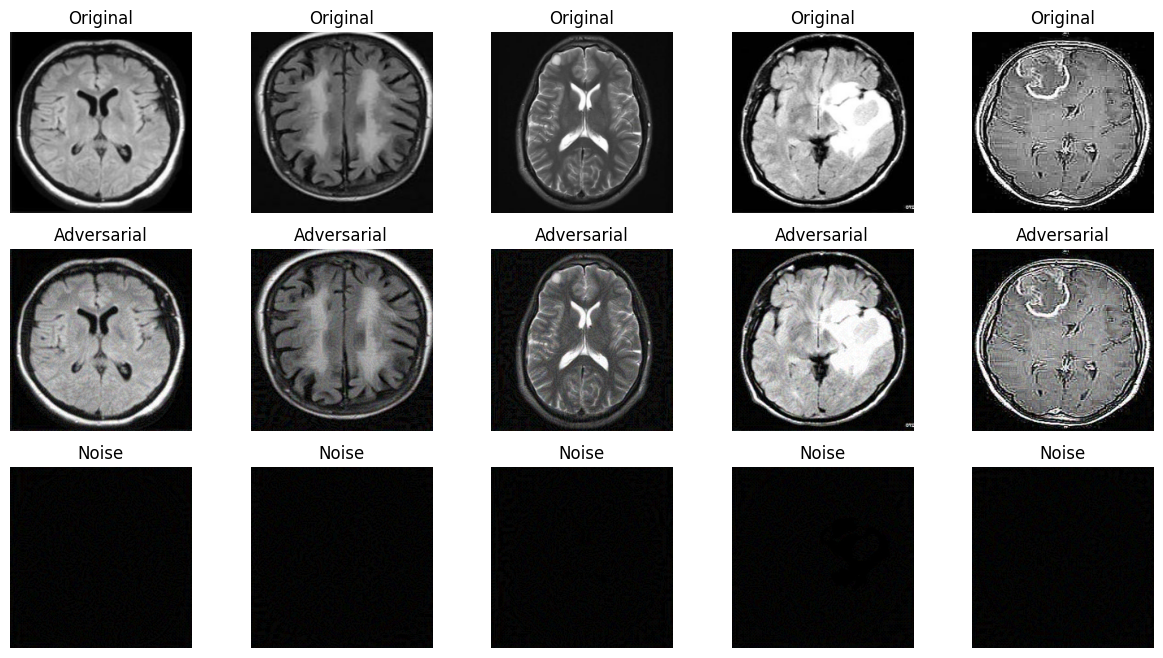

In [10]:
for images,labels in val_dataset.take(1):
  adv_images=fgsm_attack(model,images,labels,epsilon=0.03)

  plt.figure(figsize=(15,8))

  for i in range(5):
    plt.subplot(3,5,i+1)
    plt.imshow(images[i])
    plt.title("Original")
    plt.axis("off")

    plt.subplot(3,5,i+6)
    plt.imshow(adv_images[i])
    plt.title("Adversarial")
    plt.axis("off")

    plt.subplot(3,5,i+11)
    plt.imshow(adv_images[i]-images[i])
    plt.title("Noise")
    plt.axis("off")

  plt.show()


In [11]:
clean_loss, clean_acc = model.evaluate(val_dataset)

print(f"Clean Accuracy: {clean_acc*100:.2f}%")
print(f"Clean Loss: {clean_loss:.4f}")

19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 113ms/step - accuracy: 0.9834 - loss: 0.0651
Clean Accuracy: 98.34%
Clean Loss: 0.0651


In [12]:
epsilons = [0.01, 0.03, 0.05, 0.1]

fgsm_results = {}

for eps in epsilons:
    acc_list = []
    loss_list = []

    for images, labels in val_dataset:
        adv_images = fgsm_attack(model, images, labels, eps)
        loss, acc = model.evaluate(adv_images, labels, verbose=0)

        acc_list.append(acc)
        loss_list.append(loss)

    fgsm_results[eps] = {
        "accuracy": np.mean(acc_list),
        "loss": np.mean(loss_list)
    }

In [13]:
print("\n===== FGSM COMPARISON =====")
print("Condition\tEpsilon\tAccuracy\tLoss")

print(f"Clean\t\t-\t{clean_acc*100:.2f}%\t{clean_loss:.4f}")

for eps in epsilons:
    acc = fgsm_results[eps]["accuracy"]
    loss = fgsm_results[eps]["loss"]

    print(f"FGSM\t\t{eps}\t{acc*100:.2f}%\t{loss:.4f}")


===== FGSM COMPARISON =====
Condition	Epsilon	Accuracy	Loss
Clean		-	98.34%	0.0651
FGSM		0.01	2.33%	8.5846
FGSM		0.03	2.33%	8.3304
FGSM		0.05	6.63%	7.1754
FGSM		0.1	32.00%	5.1500


### Accuracy and Loss vs. Epsilon Plot

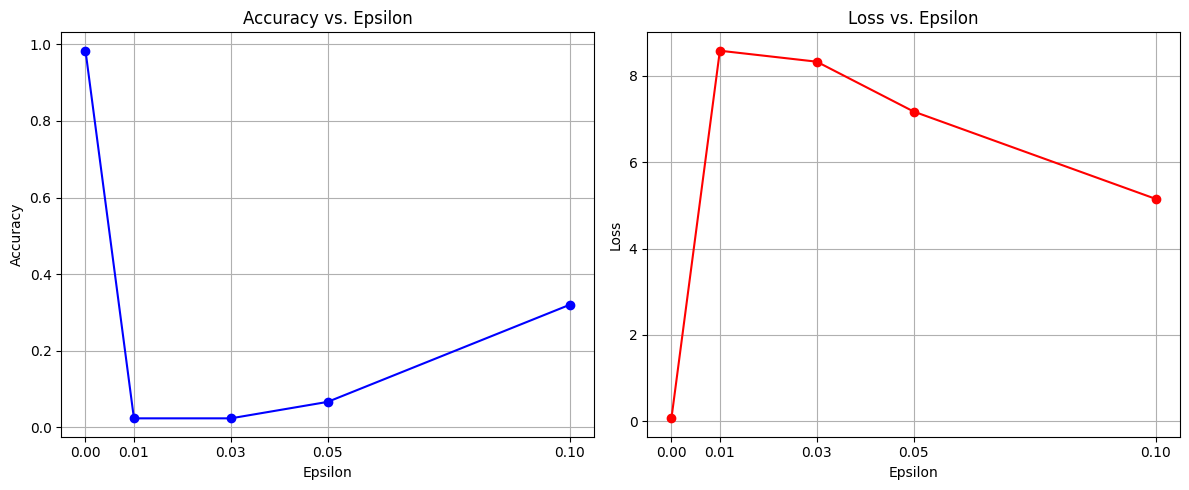

In [15]:
epsilons_plot = [0] + epsilons # Add 0 for clean data
accuracies = [clean_acc] + [fgsm_results[eps]["accuracy"] for eps in epsilons]
losses = [clean_loss] + [fgsm_results[eps]["loss"] for eps in epsilons]

plt.figure(figsize=(12, 5))

# Plotting Accuracy vs Epsilon
plt.subplot(1, 2, 1) # 1 row, 2 columns, 1st plot
plt.plot(epsilons_plot, accuracies, marker='o', linestyle='-', color='b')
plt.title('Accuracy vs. Epsilon')
plt.xlabel('Epsilon')
plt.ylabel('Accuracy')
plt.grid(True)
plt.xticks(epsilons_plot)

# Plotting Loss vs Epsilon
plt.subplot(1, 2, 2) # 1 row, 2 columns, 2nd plot
plt.plot(epsilons_plot, losses, marker='o', linestyle='-', color='r')
plt.title('Loss vs. Epsilon')
plt.xlabel('Epsilon')
plt.ylabel('Loss')
plt.grid(True)
plt.xticks(epsilons_plot)

plt.tight_layout()
plt.show()

In [14]:
np.save('fgsm_images.npy',adv_images)